# 06 — Minimizers, Gradient Flows and Gradient Descent

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

> **Central question.** *When does a functional have a minimizer, and how do we compute it by following the gradient?*

Part II studies, in their own right, the two ideas that produced every control of Part I: **minimization → existence → gradient flow → Lyapunov decay → Euler discretization → gradient descent.** The same order will be repeated for learning.

### Table of Contents

1. **Minimization everywhere** — one abstract problem behind many classical ones
2. **First-order conditions and Lagrange multipliers** — $\nabla f=\lambda\nabla g$, and the Rayleigh quotient
3. **Existence of minimizers** — continuity + coercivity, and what can fail
4. **The gradient flow and its Lyapunov function** — $J$ decreases along its own flow
5. **Euler discretization: gradient descent** — step sizes, stability, and the sharp quadratic picture
6. **Laboratory: conditioning on the quadratic landscape E3**
7. **Back to control: the HUM functional** — observability is strong convexity
8. **Control ↔ ML**
9. **Fermat's principle and Snell's law** *(optional)*
10. **Inequality constraints: linear programming and transport** *(optional)*
11. **Existence in a Hilbert space: the direct method** *(optional)*
12. **Long-time behaviour of gradient flows** *(optional)*
13. **Common misconceptions**
14. **Key takeaways**
15. **Exercises**

In [1]:
%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt
import plotting as P           # the course palette, the house style, and the figure helpers

torch.manual_seed(0);

In [2]:
# The quadratic landscape E3 and the two ways of descending it, implemented under their formulas
def quadratic_E3(kappa):
    """Q = R diag(1, kappa) R^T with R a rotation by 30°, and q chosen so that u* = (1, 0.5)."""
    c, s = np.cos(np.pi / 6), np.sin(np.pi / 6)
    R = np.array([[c, -s], [s, c]])
    Q = R @ np.diag([1.0, kappa]) @ R.T
    return Q, Q @ np.array([1.0, 0.5])

def quadratic_value(Q, q, pts):
    """J(u) = 1/2 u^T Q u - q^T u, batched over the leading dimensions of pts."""
    return 0.5 * np.einsum("...i,ij,...j->...", pts, Q, pts) - pts @ q

def gradient_descent(grad, u0, eta, n):
    """Iterates of u_{k+1} = u_k - eta grad(u_k), including u_0."""
    u, us = np.array(u0, float), []
    for _ in range(n + 1):
        us.append(u.copy())
        u = u - eta * grad(u)
    return np.array(us)

def quadratic_flow(Q, q, u0, taus):
    """Exact gradient flow of E3: u(tau) = u* + e^{-Q tau}(u0 - u*), via the eigenbasis of Q."""
    w, V = np.linalg.eigh(Q)
    u_star = np.linalg.solve(Q, q)
    coef = V.T @ (u0 - u_star)
    return u_star + (V @ (coef[:, None] * np.exp(-np.outer(w, taus)))).T

## Where are we?

> **Recap.** Every control of Part I came from a **minimization principle**. In [notebook 03](03_observability_duality_adjoints.ipynb) the HUM functional $J(\varphi_T)=\tfrac12\int_0^T|B^*\varphi|^2-\langle x^1,\varphi_T\rangle+\langle x^0,\varphi(0)\rangle$ was shown to be continuous, strictly convex and coercive, its minimizer gave the control of minimal $L^2$ norm, and its Hessian was the Gramian $\mathcal G_T$. In [notebook 04](04_structured_controls_bangbang_switching.ipynb) other functionals, $J_{bb}$ and $J_{sw}$, gave controls with structure. In [notebook 05](05_feedback_stabilization.ipynb) an **energy identity**, $\frac{d}{dt}|x|^2=-2|B^*x|^2$, gave the decay of a closed loop.

## 1. Minimization everywhere

**Idea.** One abstract problem, $\min_{u\in U}J(u)$, behind geodesics, optics, transport and training.

> *"Nothing at all takes place in the universe in which some rule of the maximum or minimum does not appear."* — L. Euler

Classical mathematics is a gallery of extremal problems: Dido's isoperimetric problem ($4\pi A\le L^2$, with equality only for the circle), geodesics as the shortest curves between two points, Fermat's principle in optics, Monge's optimal transport, and Plateau's minimal surfaces. All of them have the same abstract form:
$$
J(u^*)=\min_{u\in U}J(u),
$$
where $U$ is a set of admissible objects (points, curves, controls, shapes, network parameters) and $J:U\to\mathbb R$ measures their cost.

Two questions organize this notebook.

- **Existence.** Is the minimum attained, or is it only an infimum? (§3)
- **Computation.** How do we find $u^*$? The workhorse answer is the gradient method $u_{k+1}=u_k-\eta\nabla J(u_k)$. (§§4–6)

Before either, we recall what a minimizer must satisfy.

## 2. First-order conditions and Lagrange multipliers

**Idea.** At a constrained minimizer the gradient of the cost is normal to the constraint.

**Without constraints.** If $J:\mathbb R^n\to\mathbb R$ is differentiable and $u^*$ is a minimizer, then $\nabla J(u^*)=0$. Otherwise $J(u^*-s\nabla J(u^*))=J(u^*)-s|\nabla J(u^*)|^2+o(s)<J(u^*)$ for small $s>0$. Points with $\nabla J=0$ are **critical points**. They include minimizers, maximizers and saddles.

**With an equality constraint.** Consider
$$
\min_{g(x)=c}f(x).
$$
Critical points are those for which
$$
\nabla f(x)=\lambda\,\nabla g(x)\qquad\text{for some real }\lambda .
$$
The reason is geometric. $\nabla g(x)$ is the normal to the level set $\{g=c\}$ on which the minimization occurs. If $\nabla f(x)$ had a nontrivial projection onto the tangent space of that level set, moving along the level set against this projection would give a smaller value of $f$. The number $\lambda$ is the **Lagrange multiplier**. A rigorous version requires $\nabla g(x)\ne0$.

> **Example (the Rayleigh quotient).** Let $Q$ be symmetric and minimize $f(u)=\tfrac12u^\top Qu$ on the unit circle, $g(u)=\tfrac12|u|^2=\tfrac12$. Since $\nabla f=Qu$ and $\nabla g=u$, the Lagrange condition reads
> $$
> Qu=\lambda u :
> $$
> **the critical points on the sphere are the eigenvectors, and the multipliers are the eigenvalues.** On a critical point, $f(u)=\tfrac12\lambda$, so the minimum is $\tfrac12\lambda_{\min}(Q)$.

This is not a toy. In notebook 03 the best terminal observability constant was $c_{\rm term}=\lambda_{\min}(\mathcal G_T)=\min_{|\varphi_T|=1}\int_0^T|B^*\varphi|^2\,dt$, a constrained minimization of exactly this kind. And in notebook 03 (Exercise 2) the terminal datum of the adjoint appeared as the Lagrange multiplier of the terminal constraint $x(T)=x^1$. Multipliers become adjoints, and in [notebook 07](07_adjoints_density_heat_control.ipynb) this observation becomes a general method for computing gradients.

**Code and plot.** Minimize $f(u)=\tfrac12u^\top Qu$ on the unit circle (E3 with $\kappa=4$) and draw the two gradients at a critical and at a non-critical point.

eigenvalues of Q: [1. 4.]   min of f on the circle = 0.5
Lagrange condition at the minimizer: Q u - lambda u = [0. 0.]


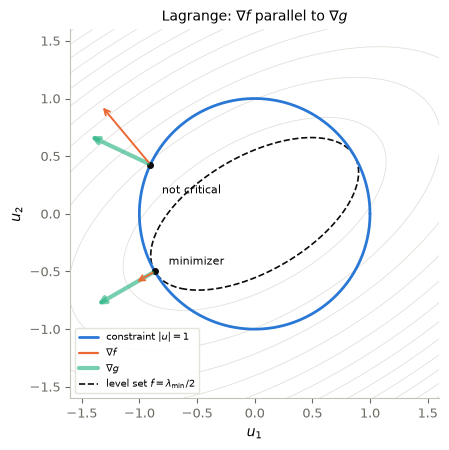

In [3]:
Q_lag, _ = quadratic_E3(4.0)
lam_lag, V_lag = np.linalg.eigh(Q_lag)
u_min = V_lag[:, 0]
print("eigenvalues of Q:", lam_lag.round(5), "  min of f on the circle =", round(0.5 * lam_lag[0], 5))
print("Lagrange condition at the minimizer: Q u - lambda u =",
      (Q_lag @ u_min - lam_lag[0] * u_min).round(12))

fig, ax = P.panels(figsize=(5.0, 4.6))
g1, g2 = np.meshgrid(np.linspace(-1.6, 1.6, 200), np.linspace(-1.6, 1.6, 200))
pts = np.stack([g1, g2], axis=-1)
vals = 0.5 * np.einsum("...i,ij,...j->...", pts, Q_lag, pts)
ax.contour(g1, g2, vals, levels=12, colors=P.GRID, linewidths=0.6)
ax.contour(g1, g2, vals, levels=[0.5 * lam_lag[0]], colors=P.INK, linewidths=1.2, linestyles="dashed")
s = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(s), np.sin(s), color=P.BLUE, lw=2, label=r"constraint $|u|=1$")
for u, name, offset in [(u_min, "minimizer", (0.12, 0.06)),
                        (np.array([np.cos(2.7), np.sin(2.7)]), "not critical", (0.1, -0.25))]:
    ax.annotate("", xy=u + 0.6 * u, xytext=u,
                arrowprops=dict(arrowstyle="->", color=P.AQUA, lw=3, alpha=0.6))
    ax.annotate("", xy=u + 0.2 * (Q_lag @ u), xytext=u,
                arrowprops=dict(arrowstyle="->", color=P.ORANGE, lw=1.4))
    ax.plot(*u, "o", color=P.INK, ms=4); ax.text(*(u + np.array(offset)), name, fontsize=8)
ax.plot([], [], color=P.ORANGE, label=r"$\nabla f$")
ax.plot([], [], color=P.AQUA, lw=3, alpha=0.6, label=r"$\nabla g$")
ax.plot([], [], color=P.INK, ls="--", lw=1.2, label=r"level set $f=\lambda_{\min}/2$")
P.label(ax, "$u_1$", "$u_2$", title=r"Lagrange: $\nabla f$ parallel to $\nabla g$",
        equal=True, legend={"loc": "lower left", "fontsize": 7})
plt.show()

At the minimizer, an eigenvector of $\lambda_{\min}$, the gradients $\nabla f$ (thin arrow) and $\nabla g$ (thick arrow) are parallel, and the level set $f=\lambda_{\min}/2$ (dashed) touches the circle there. At the non-critical point, $\nabla f$ has a component along the circle: moving against it decreases $f$, so that point cannot be a minimizer. This is the geometric content of $\nabla f=\lambda\nabla g$.

## 3. Existence of minimizers

**Idea.** Coercivity keeps minimizing sequences bounded; compactness does the rest.

> **Theorem 1 (existence in finite dimension).**
> *Assumptions:* $J:\mathbb R^n\to\mathbb R$ is continuous and coercive ($J(u)\to+\infty$ as $|u|\to\infty$).
>
> *Conclusion:* $J$ attains its minimum. If $J$ is moreover strictly convex, the minimizer is unique.

*Proof.* Let $I=\inf J$ and $J(u_n)\searrow I$. By coercivity the sequence $(u_n)$ is bounded, and in particular $I>-\infty$. By the Bolzano–Weierstrass theorem a subsequence converges, $u_n\to u^*$, and by continuity $J(u^*)=\lim J(u_n)=I$. If $J$ is strictly convex, two minimizers $u\ne v$ would give $J(\tfrac{u+v}2)<\tfrac12J(u)+\tfrac12J(v)=I$, which is impossible. $\square$

Convexity is not needed for existence in finite dimension. It matters for uniqueness, and, in infinite dimension, for existence itself: when the unknown is a function, for instance a control $u\in L^2(0,T)$, bounded sequences need not have convergent subsequences. The **direct method of the calculus of variations** then replaces compactness by *weak* compactness and continuity by *convexity*: a continuous, convex, coercive functional on a Hilbert space has a minimizer. Its four-step proof is in §11.

**This is the argument that gave the controls of Part I.** In notebook 03, coercivity of the HUM functional came from observability, and strict convexity from the same inequality; in notebook 04, $J_{bb}$ and $J_{sw}$ followed the same pattern. Each hypothesis can fail:

- without coercivity, $J(u)=e^u$ on $\mathbb R$ has infimum $0$, never attained (Exercise 1);
- without a Hilbert (reflexive) space, weak compactness fails. Minimizing the length $\int_0^1|x'(t)|\,dt$ of curves from $A$ to $B$ leads out of the Hilbert setting (§11 and Exercise 6).

## 4. The gradient flow and its Lyapunov function

**Idea.** $J$ decreases along its own gradient flow — the dissipation is the squared gradient.

To *compute* a minimizer, we let $u$ move in the direction of steepest descent. The **gradient flow** of $J$ is the ODE, in the fictitious time $\tau\ge0$,
$$
u'(\tau)=-\nabla J(u(\tau)),\qquad u(0)=u_0 .
$$
Throughout, $J\in C^1(\mathbb R^n)$ with a locally Lipschitz gradient, so that the flow is well defined.

> **Theorem 2 (Lyapunov identity).**
> *Conclusion:* along every trajectory of the gradient flow,
> $$\frac{d}{d\tau}J(u(\tau))=-|\nabla J(u(\tau))|^2\le0 .$$
>
> *Interpretation:* **$J$ is a Lyapunov function of its own gradient flow**: its value decreases along trajectories, strictly away from critical points.

*Proof.* Multiply the equation by $\nabla J(u(\tau))$: $\frac{d}{d\tau}J(u)=\langle\nabla J(u),u'\rangle=-|\nabla J(u)|^2$. $\square$

Compare with notebook 05, where $\frac{d}{dt}|x|^2=-2|B^*x|^2$: there the energy was the Lyapunov function, and the dissipation was the observation. Here the dissipation is the squared gradient.

**Consequences.**

1. If $J$ is bounded below, $J(u(\tau))$ decreases to a limit $I$, and integrating the identity gives $\int_0^\infty|\nabla J(u(\tau))|^2d\tau\le J(u_0)-I<\infty$.
2. If $J$ is coercive, the trajectory stays in the sublevel set $\{J\le J(u_0)\}$, which is bounded. In finite dimension it is therefore precompact.
3. **Critical points.** In finite dimension every accumulation point of the trajectory is a critical point (LaSalle's invariance principle; no convexity needed).
4. **The minimizer.** If $J$ is convex with a unique minimizer $u^*$, the trajectory converges to $u^*$, without a rate. Proofs of 3–4 and the infinite-dimensional case: §12.
5. **Exponential convergence under strong convexity.** Suppose
$$
\langle\nabla J(u)-\nabla J(v),u-v\rangle\ge\alpha|u-v|^2\qquad\text{for all }u,v,\quad\alpha>0 .
\tag{SC}
$$
If $u(\tau)$ and $v(\tau)$ are two trajectories, then $\frac{d}{d\tau}\tfrac12|u-v|^2=-\langle\nabla J(u)-\nabla J(v),u-v\rangle\le-\alpha|u-v|^2$, so
$$
|u(\tau)-v(\tau)|\le e^{-\alpha\tau}|u(0)-v(0)| .
$$
Taking $v\equiv u^*$, the constant trajectory at the minimizer, gives $|u(\tau)-u^*|\le e^{-\alpha\tau}|u_0-u^*|$.

## 5. Euler discretization: gradient descent

**Idea.** Gradient descent minimizes a local linear model plus a quadratic penalty for long steps — and it is explicit Euler for the gradient flow.

There are two ways to arrive at the same update, and both are worth knowing.

**As a model minimization.** The first-order Taylor expansion
$$
f(x) = f(x_k) + \langle \nabla f(x_k),\, x - x_k \rangle + o(\|x - x_k\|)
$$
is a *linear* model of the objective; when the gradient is nonzero, it is unbounded below. Adding a quadratic penalty for long steps gives a model with a unique minimizer:
$$
x_{k+1} = \arg\min_{y} \Big\{ f(x_k) + \langle \nabla f(x_k),\, y - x_k \rangle + \tfrac{1}{2\eta}\|y - x_k\|^2 \Big\}
= x_k - \eta \nabla f(x_k).
$$
The gradient picks the direction; the **step size** $\eta>0$ picks how far.

**As a time discretization.** The same update is the **explicit Euler** scheme for the gradient flow of §4 with time step $\eta$:
$$
u_{k+1}=u_k-\eta\,\nabla J(u_k),\qquad k=0,1,2,\dots
$$
After $k$ steps the iterate approximates $u(\tau)$ at $\tau=k\eta$.

**Code and plot.** Four step sizes on one diagonal quadratic ($\tfrac12(x_1^2+20x_2^2)$): the four regimes of the method.

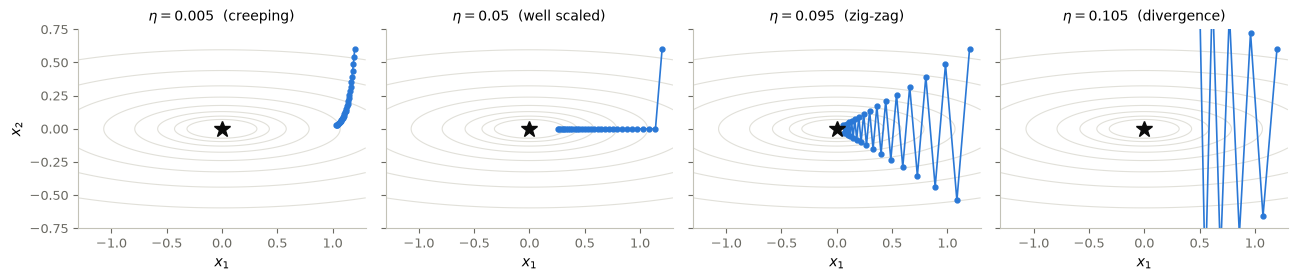

In [4]:
a1, a2 = 1.0, 20.0
f_diag = lambda x: 0.5 * (x[..., 0] ** 2 * a1 + x[..., 1] ** 2 * a2)
grad_diag = lambda x: np.array([a1, a2]) * x

g1, g2 = np.meshgrid(np.linspace(-1.3, 1.3, 300), np.linspace(-0.75, 0.75, 300))
Z = f_diag(np.stack([g1, g2], -1))

fig, axes = P.panels(4, size=(3.25, 2.9), sharex=True, sharey=True)
for ax, (c, note) in zip(axes, [(0.1, "creeping"), (1, "well scaled"),
                                (1.9, "zig-zag"), (2.1, "divergence")]):
    P.contour_path(ax, g1, g2, Z, path=gradient_descent(grad_diag, [1.2, 0.6], c / a2, 8 if c > 2 else 30),
                   optimum=(0, 0), color=P.BLUE, marker="-o", levels=np.geomspace(0.05, 12, 10),
                   xlabel="$x_1$", xlim=(-1.3, 1.3), ylim=(-0.75, 0.75),
                   title=rf"$\eta = {c / a2:g}$  ({note})")
axes[0].set_ylabel("$x_2$")
plt.show()

With $\eta\lambda_{\max}$ well below $1$ the iterates creep; near $1$ they move straight to the minimizer; between $1$ and $2$ the fast component overshoots and zigzags but still converges; beyond $2$ it is amplified at every step and the method diverges. The next theorem and the sharp quadratic analysis below turn this picture into statements.

> **Theorem 3 (convergence of gradient descent).**
> *Assumptions:* $\nabla J$ satisfies (SC) with $\alpha>0$, and it is Lipschitz: $|\nabla J(u)-\nabla J(v)|^2\le M|u-v|^2$, with $M=L^2$.
>
> *Conclusion:* with $u^*$ the minimizer,
> $$|u_k-u^*|\le\big(1-2\eta\alpha+\eta^2M\big)^{k/2}|u_0-u^*| ,$$
> and the iterates converge linearly whenever $0<\eta<2\alpha/M$, a *sufficient*, not optimal, range. The best factor in this bound is obtained at $\eta=\alpha/M$, where it equals $\sqrt{1-\alpha^2/M}$.
>
> *Interpretation:* gradient descent inherits the contraction of the gradient flow, *provided the time step is small compared with the fastest scale of the problem*.

*Proof.* Since $\nabla J(u^*)=0$, the error $e_k=u_k-u^*$ satisfies $e_{k+1}=e_k-\eta\big(\nabla J(u_k)-\nabla J(u^*)\big)$. Expanding the square and using both assumptions,
$$
|e_{k+1}|^2=|e_k|^2-2\eta\langle\nabla J(u_k)-\nabla J(u^*),e_k\rangle+\eta^2|\nabla J(u_k)-\nabla J(u^*)|^2\le(1-2\eta\alpha+\eta^2M)\,|e_k|^2 .
$$
The factor is smaller than $1$ exactly when $\eta(\eta M-2\alpha)<0$, that is, when $0<\eta<2\alpha/M$. Minimizing it over $\eta$ gives $\eta=\alpha/M$. $\square$

**Quadratics: the sharp picture.** For the example E3,
$$
J(u)=\tfrac12u^\top Qu-q^\top u,\qquad\nabla J(u)=Qu-q,\qquad u^*=Q^{-1}q,
$$
with $Q$ symmetric positive definite and eigenvalues $\lambda_{\min}=\lambda_1\le\dots\le\lambda_n=\lambda_{\max}$, the error obeys exactly
$$
e_{k+1}=(I-\eta Q)\,e_k .
$$
Along the eigenvector $v_j$ of $Q$ it is multiplied by $1-\eta\lambda_j$ at every step. Hence

- GD converges from every $u_0$ **if and only if** $|1-\eta\lambda_j|<1$ for all $j$, that is, $0<\eta<2/\lambda_{\max}$. If $\eta>2/\lambda_{\max}$, the component along $v_n$ is amplified by $|1-\eta\lambda_{\max}|>1$ at each step, and the iterates blow up;
- the factor $\max_j|1-\eta\lambda_j|$ is smallest at $\eta=2/(\lambda_{\min}+\lambda_{\max})$, where it equals $\dfrac{\kappa-1}{\kappa+1}$, with $\kappa=\lambda_{\max}/\lambda_{\min}$;
- reducing the error by a factor $\delta$ therefore takes about $\dfrac{\ln(1/\delta)}{\ln\frac{\kappa+1}{\kappa-1}}\approx\dfrac\kappa2\ln(1/\delta)$ steps when $\kappa$ is large.

The flow itself contracts the component along $v_j$ by $e^{-\lambda_j\tau}$, so its slowest time scale is $1/\lambda_{\min}$. The Euler scheme is stable only if $\eta<2/\lambda_{\max}$, the fastest time scale. **An ill-conditioned problem is a stiff ODE**: the number of steps is governed by the ratio of the two scales, the condition number $\kappa$. The convergence of the optimization method and the stability of the time discretization are one and the same condition.

For E3, $\alpha=\lambda_{\min}$ and $L=\lambda_{\max}$, so Theorem 3 guarantees convergence only for $\eta<2\lambda_{\min}/\lambda_{\max}^2$, smaller than the sharp threshold $2/\lambda_{\max}$ by the factor $\kappa$. The theorem only uses (SC) and the Lipschitz bound, and it holds for maps that are not gradients, for which it is sharp (Exercise 4). For gradients of convex functions, the range $0<\eta<2/L$ is known to suffice; we state this without proof.

### 5.1 The descent lemma, and rates without strong convexity

Strong convexity is a luxury that the losses of Part III rarely offer. Two weaker and far more common settings still give guarantees, and both rest on one inequality.

> **Assumption ($L$-smoothness).** $J$ is differentiable and $\nabla J$ is $L$-Lipschitz:
>
> $$\|\nabla J(u) - \nabla J(v)\| \le L \|u - v\| \qquad \forall u, v,$$
>
> equivalently $-L I \preceq \nabla^2 J(u) \preceq L I$ when $J$ is twice differentiable. Curvature is bounded, so the gradient measured at $u$ stays informative over steps controlled by the curvature scale $L$ — and nothing forces $J$ to be convex.

> **Lemma (descent lemma).**
> $$J(v) \le J(u) + \langle \nabla J(u),\, v - u\rangle + \frac{L}{2}\|v - u\|^2 \qquad \forall u, v.$$

*Proof.* Write the increment along the segment $u + t(v-u)$, $t \in [0,1]$, with the fundamental theorem of calculus:

$$J(v) - J(u) - \langle \nabla J(u), v - u\rangle = \int_0^1 \big\langle \nabla J\big(u + t(v-u)\big) - \nabla J(u),\ v - u \big\rangle \, dt.$$

Bound the integrand with Cauchy–Schwarz and then with the Lipschitz assumption, $\|\nabla J(u + t(v-u)) - \nabla J(u)\| \le L t \|v-u\|$:

$$\le \int_0^1 L t \|v-u\|^2 \, dt = \frac{L}{2}\|v-u\|^2. \qquad \square$$

This is the whole mechanism in one line: **the quadratic model minimized at the start of this section is a global upper bound on $J$ as soon as $1/\eta \ge L$.** Minimizing an upper bound that touches $J$ at $u_k$ cannot increase $J$.

> **Theorem 4 (decay of the gradient).** Let $J$ be $L$-smooth and bounded below by $J^\star$, and let $0 < \eta \le 1/L$. Then gradient descent satisfies
>
> $$J(u_{k+1}) \le J(u_k) - \frac{\eta}{2}\|\nabla J(u_k)\|^2 \qquad\text{and}\qquad \min_{0 \le k < K} \|\nabla J(u_k)\|^2 \le \frac{2\big(J(u_0) - J^\star\big)}{\eta K}.$$

*Proof.* Apply the lemma with $u = u_k$ and $v = u_{k+1} = u_k - \eta\nabla J(u_k)$:

$$J(u_{k+1}) \le J(u_k) - \eta\|\nabla J(u_k)\|^2 + \frac{L\eta^2}{2}\|\nabla J(u_k)\|^2 = J(u_k) - \eta\Big(1 - \frac{L\eta}{2}\Big)\|\nabla J(u_k)\|^2,$$

and $\eta L \le 1$ gives $1 - L\eta/2 \ge 1/2$, which is the first claim. Summing it for $k = 0, \dots, K-1$ telescopes:

$$\frac{\eta}{2}\sum_{k=0}^{K-1}\|\nabla J(u_k)\|^2 \le J(u_0) - J(u_K) \le J(u_0) - J^\star,$$

and the minimum of $K$ terms is at most their average. $\square$

> **Theorem 5 (convex case).** If in addition $J$ is convex with a minimizer $u^\star$ and $0 < \eta \le 1/L$, then
>
> $$J(u_K) - J^\star \le \frac{\|u_0 - u^\star\|^2}{2\eta K}.$$

*Proof.* Expand the distance to $u^\star$ and use convexity, $\langle \nabla J(u_k), u_k - u^\star\rangle \ge J(u_k) - J^\star$:

$$\|u_{k+1} - u^\star\|^2 = \|u_k - u^\star\|^2 - 2\eta \langle \nabla J(u_k), u_k - u^\star\rangle + \eta^2\|\nabla J(u_k)\|^2 \le \|u_k - u^\star\|^2 - 2\eta\big(J(u_k) - J^\star\big) + \eta^2 \|\nabla J(u_k)\|^2 .$$

Theorem 4 bounds the last term by the achieved decrease, $\eta^2\|\nabla J(u_k)\|^2 \le 2\eta\,(J(u_k) - J(u_{k+1}))$, so

$$\|u_{k+1} - u^\star\|^2 \le \|u_k - u^\star\|^2 - 2\eta\big(J(u_{k+1}) - J^\star\big).$$

Summing over $k < K$ telescopes the left side, and $J(u_k)$ is non-increasing, so the $K$ remaining terms are all at least $J(u_K) - J^\star$:

$$2\eta K \big(J(u_K) - J^\star\big) \le \sum_{k=0}^{K-1} 2\eta\big(J(u_{k+1}) - J^\star\big) \le \|u_0 - u^\star\|^2 - \|u_K - u^\star\|^2 \le \|u_0 - u^\star\|^2 . \qquad \square$$

| Assumptions | Measure | Rate | Iterations to reach the stated tolerance |
|---|---|---|---|
| $L$-smooth, bounded below | $\min_k \lVert\nabla J(u_k)\rVert^2$ | $O(1/K)$ | $O(\varepsilon^{-2})$ for $\lVert\nabla J\rVert \le \varepsilon$ |
| $L$-smooth and convex, with a minimizer | $J(u_K) - J^\star$ | $O(1/K)$ | $O(\varepsilon^{-1})$ for $J(u_K)-J^\star \le \varepsilon$ |
| $L$-smooth and strongly convex (Theorem 3) | $\lvert u_K - u^\star\rvert$ | linear | $O(\ln(1/\varepsilon))$ |

These are the guarantees that survive when training replaces the quadratic landscapes of this notebook by a loss built from data (notebook 10, which also treats the stochastic versions).

## 6. Laboratory: conditioning on the quadratic landscape E3

**Idea.** The condition number is visible: narrow valleys, zigzags, and step counts that grow like $\kappa$.

We use E3 in $\mathbb R^2$ with $Q=R\,\mathrm{diag}(1,\kappa)R^\top$, a rotation $R$ by $30°$, so that $\lambda_{\min}=1$ and $\lambda_{\max}=\kappa$, and minimizer $u^*=(1,0.5)$. Starting from $u_0=(-1.5,1.5)$, we compare the exact gradient flow with gradient descent at the best step $\eta=2/(\lambda_{\min}+\lambda_{\max})$, for $\kappa=1,10,100$.

**Code and plot.** Level sets, the flow, and the first 25 GD iterates; the titles count the steps to reduce the error by $10^{-6}$.

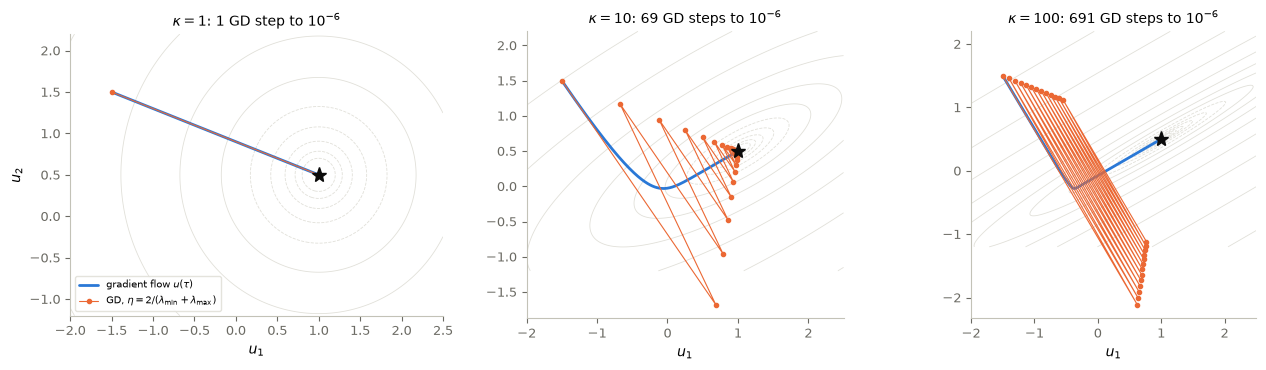

steps to reduce the error by 1e-6 at the best step: {1.0: 1, 10.0: 69, 100.0: 691}
prediction ln(1e6)/ln((kappa+1)/(kappa-1)): {10.0: 68.8, 100.0: 690.8}


In [5]:
kappas = [1.0, 10.0, 100.0]
u0 = np.array([-1.5, 1.5])
steps_to_1e6 = {}

fig, axes = P.panels(3, size=(4.4, 3.8))
g1, g2 = np.meshgrid(np.linspace(-2.0, 2.5, 220), np.linspace(-1.2, 2.2, 220))
for ax, kappa in zip(axes, kappas):
    Q, q = quadratic_E3(kappa)
    lam_min, lam_max = np.linalg.eigvalsh(Q)
    u_star = np.linalg.solve(Q, q)
    eta = 2 / (lam_min + lam_max)
    flow = quadratic_flow(Q, q, u0, np.linspace(0, 10, 600))
    gd = gradient_descent(lambda u: Q @ u - q, u0, eta, 2000)
    errors = np.linalg.norm(gd - u_star, axis=1) / np.linalg.norm(u0 - u_star)
    steps_to_1e6[kappa] = int(np.argmax(errors <= 1e-6))
    J_star = quadratic_value(Q, q, u_star)
    ax.contour(g1, g2, quadratic_value(Q, q, np.stack([g1, g2], axis=-1)),
               levels=np.geomspace(0.02, 200, 14) + J_star, colors=P.GRID, linewidths=0.6)
    ax.plot(*flow.T, color=P.BLUE, lw=2, label=r"gradient flow $u(\tau)$")
    ax.plot(*gd[:26].T, "o-", color=P.ORANGE, ms=3, lw=0.8,
            label=r"GD, $\eta=2/(\lambda_{\min}+\lambda_{\max})$")
    ax.plot(*u_star, "*", color=P.INK, ms=11)
    n_steps = steps_to_1e6[kappa]
    P.label(ax, "$u_1$", "$u_2$" if kappa == 1 else None, equal=True,
            title=rf"$\kappa={kappa:g}$: {n_steps} GD step{'s' if n_steps > 1 else ''} to $10^{{-6}}$",
            legend={"fontsize": 7, "loc": "lower left"} if kappa == 1 else False)
plt.show()
print("steps to reduce the error by 1e-6 at the best step:", steps_to_1e6)
print("prediction ln(1e6)/ln((kappa+1)/(kappa-1)):",
      {k: round(float(np.log(1e6) / np.log((k + 1) / (k - 1))), 1) for k in kappas[1:]})

For $\kappa=1$ the level sets are circles, $-\nabla J$ points at the minimizer, and **one step** with $\eta=1$ lands on it. As $\kappa$ grows, the level sets become long narrow valleys. The flow first falls quickly into the valley, along the fast direction, and then crawls along it. Gradient descent at the best step overshoots across the valley and zigzags, because the fast component is multiplied by $1-\eta\lambda_{\max}\approx-1$. Going from $\kappa=10$ to $\kappa=100$ multiplies the number of steps by about $10$, as the estimate $\tfrac\kappa2\ln(10^6)$ predicts, and the printed counts agree with it.

**Code and plot.** Error curves for two step-size choices, and the step-size sweep for $\kappa=10$: what happens $1\%$ above the stability threshold?

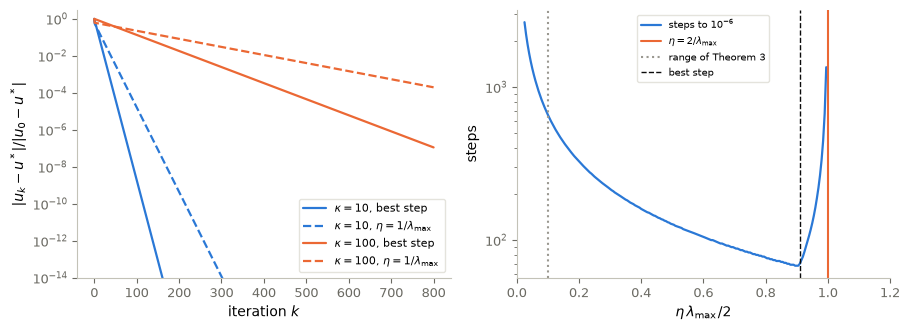

kappa = 10, eta = 0.99 x 2/lambda_max: error after 300 steps = 4.936e-03
kappa = 10, eta = 1.01 x 2/lambda_max: error after 300 steps = 8.046e+02


In [6]:
fig, (ax1, ax2) = P.panels(2, size=(4.6, 3.4))
for kappa, color in zip(kappas[1:], (P.BLUE, P.ORANGE)):
    Q, q = quadratic_E3(kappa)
    u_star = np.linalg.solve(Q, q)
    for eta, style, name in [(2 / (1 + kappa), "-", "best step"), (1 / kappa, "--", r"$\eta=1/\lambda_{\max}$")]:
        gd = gradient_descent(lambda u: Q @ u - q, u0, eta, 800)
        ax1.semilogy(np.linalg.norm(gd - u_star, axis=1) / np.linalg.norm(u0 - u_star),
                     style, color=color, label=rf"$\kappa={kappa:g}$, {name}")
P.label(ax1, "iteration $k$", r"$|u_k-u^*|/|u_0-u^*|$", ylim=(1e-14, 3))

Q, q = quadratic_E3(10.0)
u_star = np.linalg.solve(Q, q)
lam_max = np.linalg.eigvalsh(Q)[-1]
ratios = np.linspace(0.02, 1.2, 237)

def steps_to_tolerance(eta, n_max=3000, tol=1e-6):
    # Number of GD steps until the relative error is below tol; -1 if not reached in n_max steps.
    with np.errstate(over="ignore", invalid="ignore"):     # divergent steps overflow on purpose
        iterates = gradient_descent(lambda u: Q @ u - q, u0, eta, n_max)
        rel = np.linalg.norm(iterates - u_star, axis=1) / np.linalg.norm(u0 - u_star)
    return int(np.argmax(rel <= tol)) if (rel <= tol).any() else -1

counts = np.array([steps_to_tolerance(2 * r / lam_max) for r in ratios], dtype=float)
ax2.semilogy(ratios, np.where(counts > 0, counts, np.nan), color=P.BLUE,
             label="steps to $10^{-6}$")
ax2.axvline(1.0, color=P.ORANGE, lw=1.5, label=r"$\eta=2/\lambda_{\max}$")
ax2.axvline(1 / 10, color=P.GREY, ls=":", lw=1.5, label=r"range of Theorem 3")
ax2.axvline(10 / 11, color=P.INK, ls="--", lw=1, label="best step")
P.label(ax2, r"$\eta\,\lambda_{\max}/2$", "steps", xlim=(0, 1.2),
        legend={"fontsize": 7, "loc": "upper center"})
plt.show()

for r in (0.99, 1.01):
    gd = gradient_descent(lambda u: Q @ u - q, u0, 2 * r / lam_max, 300)
    print(f"kappa = 10, eta = {r:.2f} x 2/lambda_max: "
          f"error after 300 steps = {np.linalg.norm(gd[-1] - u_star):.3e}")

All error curves are straight lines on the logarithmic scale: the convergence is linear, with the factor predicted in §5. The step $1/\lambda_{\max}$ is safe but about twice as slow as the best step. In the right panel the number of steps falls as $\eta$ grows, until just below the threshold; where no point is drawn, the method did not converge in 3000 steps. At $2/\lambda_{\max}$ the method stops converging: with $\eta$ only $1\%$ above the threshold, the printed error after 300 steps has *grown* by orders of magnitude, while $1\%$ below it the error has decreased. The range of Theorem 3 (dotted) is a factor $\kappa$ more cautious than necessary for this quadratic.

## 7. Back to control: the HUM functional

**Idea.** The strong-convexity constant of the dual control problem is the observability constant.

**HUM converts controllability into the minimization of a coercive functional.** In notebook 03, observability made the dual functional coercive, the existence result of §3 gave a minimizer, and the control was read off it. This section adds the computational side.

Notebook 03 already ran gradient descent on the HUM functional, $\nabla J(\varphi_T)=\mathcal G_T\varphi_T-d$, with $\eta=1/\lambda_{\max}$, and found a number of steps growing like $\kappa(\mathcal G_T)$ (notebook 03, §10). We do not repeat that experiment. The theory of §5 now explains it: **the HUM functional is an E3 quadratic with $Q=\mathcal G_T$.** In the language of Theorem 3,
$$
\alpha=\lambda_{\min}(\mathcal G_T)=c_{\rm term},\qquad L=\lambda_{\max}(\mathcal G_T),\qquad\kappa=\kappa(\mathcal G_T).
$$
The strong-convexity constant of the dual problem is the **observability constant**. A weakly observable system is a badly conditioned optimization problem.

**Code and check.** Evaluate these constants for the systems of notebook 03, with $T=5$.

In [7]:
def gramian(A, B, T, n_quad=400):
    """G_T = ∫_0^T e^{A(T-s)} B Bᵀ e^{Aᵀ(T-s)} ds, by the trapezoid rule (notebook 02)."""
    taus = torch.linspace(0, T, n_quad + 1).double()
    integrand = torch.stack([(E := torch.matrix_exp(A * tau)) @ B @ B.T @ E.T for tau in taus])
    return torch.trapezoid(integrand, taus, dim=0)

A1 = torch.tensor([[0.0, 1.0], [-1.0, 0.0]]).double()
B1 = torch.tensor([[0.0], [1.0]]).double()
systems = {"E1": (A1, B1)}
for eps in (1.0, 0.1, 0.01):
    A2 = torch.tensor([[0.0, 1.0, 0.0], [-1.0, 0.0, 0.0], [0.0, 0.0, -1.0]]).double()
    systems[f"E2, eps = {eps}"] = (A2, torch.tensor([[0.0], [1.0], [eps]]).double())

print(f"{'system':14s} {'alpha = c_term':>15s} {'L = lam_max':>12s} {'kappa':>11s}"
      f" {'best-step factor':>17s} {'steps to 1e-6 (est.)':>21s}")
for name, (A_s, B_s) in systems.items():
    lam = torch.linalg.eigvalsh(gramian(A_s, B_s, 5.0)).numpy()
    kappa_G = lam[-1] / lam[0]
    factor = (kappa_G - 1) / (kappa_G + 1)
    print(f"{name:14s} {lam[0]:15.3e} {lam[-1]:12.3f} {kappa_G:11.3e} {factor:17.8f}"
          f" {np.log(1e6) / -np.log(factor):21.0f}")

system          alpha = c_term  L = lam_max       kappa  best-step factor  steps to 1e-6 (est.)
E1                   2.021e+00        2.979   1.475e+00        0.19177487                     8
E2, eps = 1.0        3.113e-01        3.164   1.016e+01        0.82079978                    70
E2, eps = 0.1        3.311e-03        2.981   9.002e+02        0.99778084                  6219


E2, eps = 0.01       3.313e-05        2.979   8.992e+04        0.99997776                621172


For E1 a handful of steps suffices. For E2 the condition number grows like $\varepsilon^{-2}$ (notebook 03), so the estimated number of steps for $\varepsilon=0.01$ is in the hundreds of thousands, even at the best step. The control problem has not become harder in the yes/no sense: the system is controllable for every $\varepsilon>0$. What has become harder is the *computation*. The same mechanism, ill-conditioning inherited from weak observability, is much stronger for discretized PDEs, the subject of [notebook 07](07_adjoints_density_heat_control.ipynb).

## 8. Control ↔ ML

**Idea.** Training *is* this notebook, with a loss built from data.

- **Training is gradient descent** (a direct connection). Training a learning machine means minimizing a loss $J(w)$ over the parameters $w$ by the same update $w_{k+1}=w_k-\eta\nabla J(w_k)$. The step size is called the *learning rate*, and the stability threshold of §5 becomes the familiar observation that too large a learning rate makes training diverge (notebook 10). What changes is the loss: it is built from data, and it is rarely quadratic or convex.
- **Conditioning.** Narrow valleys, zigzags and the factor $\kappa$ motivate momentum methods, the heavy ball of notebook 05, §8 ([notebook 11](11_optimization.ipynb)).
- **Multipliers and adjoints.** Lagrange multipliers became adjoint states in notebook 03. Computing gradients through a dynamical constraint with an adjoint is [notebook 07](07_adjoints_density_heat_control.ipynb), where the link with backpropagation becomes a direct one ([notebook 13](13_neuralodes.ipynb)).
- **Transport and linear programming** (§10). They return in neural transport (notebook 16), in diffusion models ([notebook 17](17_diffusion_models.ipynb)) and in sparse shallow networks (notebook 12).

## 9. Fermat's principle and Snell's law

*Optional.*

**Fermat's principle** states that light follows the path of shortest *optical length*, that is, of least travel time, between two points. Light travels from a point at height $a$ above a flat interface, in a medium where its speed is $v_1$, to a point at depth $b$ below it, where its speed is $v_2$, at horizontal distance $\ell$. If it crosses the interface at horizontal position $x$, the travel time is
$$
T(x)=\frac{\sqrt{a^2+x^2}}{v_1}+\frac{\sqrt{b^2+(\ell-x)^2}}{v_2}.
$$
Fermat found the problem too difficult for an analytical treatment; the computation was carried out by Leibniz in 1684. Today it takes two lines:
$$
T'(x)=\frac1{v_1}\frac{x}{\sqrt{a^2+x^2}}-\frac1{v_2}\frac{\ell-x}{\sqrt{b^2+(\ell-x)^2}} .
$$
With $\sin\theta_1=x/\sqrt{a^2+x^2}$ and $\sin\theta_2=(\ell-x)/\sqrt{b^2+(\ell-x)^2}$, the angles to the normal, $T'(x)=0$ is **Snell's law**:
$$
\frac{\sin\theta_1}{\sin\theta_2}=\frac{v_1}{v_2}.
$$
Moreover
$$
T''(x)=\frac1{v_1}\frac{a^2}{(a^2+x^2)^{3/2}}+\frac1{v_2}\frac{b^2}{(b^2+(\ell-x)^2)^{3/2}}>0,
$$
so $T$ is strictly convex, and the critical point is the unique minimizer. This is the pattern of §§2–3 in miniature: a first-order condition identifies the candidate, and convexity certifies it.

**Code and plot.** Take $a=b=1$, $\ell=2$ and light twice as slow below the interface. The straight segment crosses at $x=1$ — does the least-time path cross to its left or its right?

crossing point x = 1.538264;  sin(theta1)/sin(theta2) = 2.000000;  v1/v2 = 2.000000


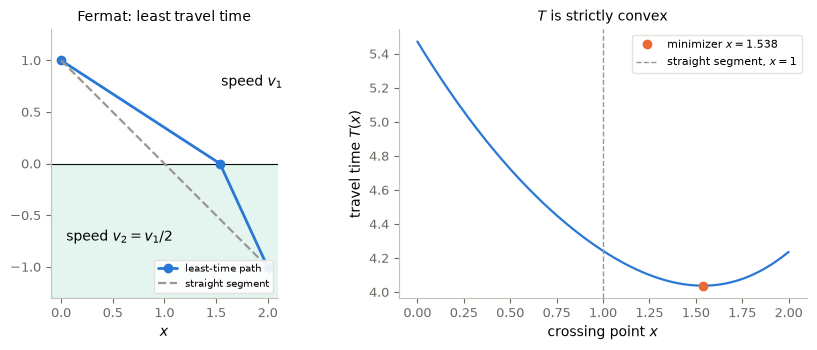

In [8]:
a, b, ell, v1, v2 = 1.0, 1.0, 2.0, 1.0, 0.5
travel_time = lambda x: np.sqrt(a ** 2 + x ** 2) / v1 + np.sqrt(b ** 2 + (ell - x) ** 2) / v2
dT = lambda x: x / (v1 * np.hypot(a, x)) - (ell - x) / (v2 * np.hypot(b, ell - x))

lo, hi = 0.0, ell                                      # T is strictly convex: bisect T'(x) = 0
for _ in range(80):
    mid = (lo + hi) / 2
    lo, hi = (mid, hi) if dT(mid) < 0 else (lo, mid)
x_snell = (lo + hi) / 2
sin1, sin2 = x_snell / np.hypot(a, x_snell), (ell - x_snell) / np.hypot(b, ell - x_snell)
print(f"crossing point x = {x_snell:.6f};  sin(theta1)/sin(theta2) = {sin1 / sin2:.6f};"
      f"  v1/v2 = {v1 / v2:.6f}")

fig, axes = P.panels(2, size=(4.4, 3.6))
axes[0].axhspan(-1.3, 0, color=P.AQUA, alpha=0.12)
axes[0].axhline(0, color=P.INK, lw=0.8)
axes[0].plot([0, x_snell, ell], [a, 0, -b], "-o", color=P.BLUE, lw=2, label="least-time path")
axes[0].plot([0, ell], [a, -b], "--", color=P.GREY, label="straight segment")
axes[0].text(1.55, 0.75, "speed $v_1$", fontsize=10)
axes[0].text(0.05, -0.75, "speed $v_2=v_1/2$", fontsize=10)
P.label(axes[0], "$x$", title="Fermat: least travel time", xlim=(-0.1, 2.1), ylim=(-1.3, 1.3),
        equal=True, legend={"fontsize": 7, "loc": "lower right"})

xs = np.linspace(0, ell, 400)
axes[1].plot(xs, travel_time(xs), color=P.BLUE)
axes[1].plot(x_snell, travel_time(x_snell), "o", color=P.ORANGE, label=f"minimizer $x={x_snell:.3f}$")
axes[1].axvline(1.0, color=P.GREY, ls="--", lw=1, label="straight segment, $x=1$")
P.label(axes[1], "crossing point $x$", "travel time $T(x)$", title="$T$ is strictly convex")
plt.show()

The light crosses to the **right** of $x=1$, at $x\approx1.538$. It shortens its path in the slow medium at the price of a longer path in the fast one, and the printed ratio $\sin\theta_1/\sin\theta_2$ equals $v_1/v_2=2$, as Snell's law requires. The shortest path is not the fastest one.

## 10. Inequality constraints: linear programming and transport

*Optional.*

In many problems the constraints are inequalities, and the minimizer lies on the boundary of the admissible set, where $\nabla J$ need not vanish. The classic example is **linear programming**. A company stores $s_i$ items in each of $M$ storage locations, $N$ clients request $r_j$ items each, and transporting one item from location $i$ to client $j$ costs $c_{ij}$. The unknowns are the amounts $v_{ij}$ delivered from $i$ to $j$, and the problem is
$$
\min_{\{v_{ij}\}}\ \sum_{i=1}^M\sum_{j=1}^Nc_{ij}v_{ij}
\quad\text{subject to}\quad v_{ij}\ge0,\qquad\sum_{j=1}^Nv_{ij}\le s_i,\qquad\sum_{i=1}^Mv_{ij}=r_j .
$$
The cost is linear and the admissible set is a polytope. A minimizer, when it exists, can always be found at a vertex. Such problems are solved by dedicated algorithms (simplex and interior-point methods), not by following the gradient, which is constant; software for them is widely available.

**Discrete optimal transport.** Take $M=N$ points $X_i$ (piles of sand, *déblais*) and $Y_j$ (holes, *remblais*), each carrying mass $1/N$, and the cost $c_{ij}=|X_i-Y_j|^2$. The transportation LP with $s_i=r_j=1/N$ and equality in all constraints asks for the cheapest way to move the first distribution onto the second. By the Birkhoff–von Neumann theorem (stated here without proof), the vertices of this polytope are exactly the permutation matrices divided by $N$ — so the LP optimum is attained at a **matching**, and for $N=8$ we can afford to find it by checking all $8!$ matchings directly. We use the example E8: an empirical sample of a Gaussian $\rho_0$ and one of the uniform distribution $\rho_T$ on $[0,1]^2$.

**Code and plot.** The optimal matching between the two samples of E8.

optimal transport cost = 1.114275   (best of 40320 matchings)


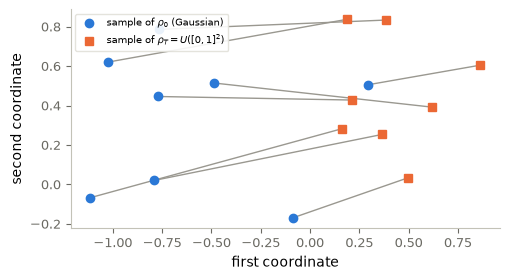

In [9]:
from itertools import permutations

torch.manual_seed(6)
N = 8
X0 = (0.35 * torch.randn(N, 2) + torch.tensor([-0.6, 0.4])).numpy()   # E8: sample of a Gaussian
X1 = torch.rand(N, 2).numpy()                                         # E8: sample of U([0,1]^2)
cost = ((X0[:, None, :] - X1[None, :, :]) ** 2).sum(axis=-1)

perms = np.array(list(permutations(range(N))))         # all 8! = 40320 matchings
costs = cost[np.arange(N), perms].sum(axis=1)
sigma = perms[costs.argmin()]
ot_cost = costs.min() / N                              # each point carries mass 1/N
print(f"optimal transport cost = {ot_cost:.6f}   (best of {len(perms)} matchings)")

fig, ax = P.panels(figsize=(5.2, 4.6))
for i in range(N):
    ax.plot([X0[i, 0], X1[sigma[i], 0]], [X0[i, 1], X1[sigma[i], 1]], color=P.GREY, lw=1)
ax.plot(*X0.T, "o", color=P.BLUE, label=r"sample of $\rho_0$ (Gaussian)")
ax.plot(*X1.T, "s", color=P.ORANGE, label=r"sample of $\rho_T=U([0,1]^2)$")
P.label(ax, "first coordinate", "second coordinate", equal=True,
        legend={"fontsize": 7, "loc": "upper left"})
plt.show()

The optimal plan is a **permutation**: each Gaussian point is sent, whole, to one uniform point, and the printed cost is the smallest total of squared displacements over all ways of matching the two samples — exactly the vertex structure that Birkhoff–von Neumann predicts for the LP. The same example returns in notebook 16, where a neural ODE transports $\rho_0$ to $\rho_T$, and LP returns in notebook 12 for sparse shallow networks.

## 11. Existence in a Hilbert space: the direct method

*Optional.*

> **Theorem 1′ (direct method of the calculus of variations).**
> *Assumptions:* $H$ is a Hilbert space, and $J:H\to\mathbb R$ is continuous, convex and coercive ($J(u)\to+\infty$ as $\|u\|\to\infty$).
>
> *Conclusion:* $J$ attains its minimum: there is $u^*\in H$ with $J(u^*)=\min_{u\in H}J(u)$.

*Proof.*

**Step 1.** Define $I=\inf_{u\in H}J(u)$. By coercivity, $I>-\infty$: outside a large ball $J$ is larger than $J(0)$, and inside it a continuous convex function is bounded below, because it lies above a continuous affine function.

**Step 2.** Take a **minimizing sequence** $(u_n)$ with $J(u_n)\searrow I$. By coercivity, $(u_n)$ is bounded in $H$.

**Step 3.** $H$ being a Hilbert space, a bounded sequence has a **weakly convergent** subsequence, $u_n\rightharpoonup u^*$ in $H$.

**Step 4.** $J$ being continuous and convex, it is **lower semicontinuous** for the weak topology. Therefore
$$
J(u^*)\le\liminf_{n\to\infty}J(u_n)=I,
$$
and by the definition of the infimum $J(u^*)=I$. $\square$

**Weak lower semicontinuity (Step 4).** In a Hilbert space a continuous function need not be weakly lower semicontinuous. For example, $J(u)=\big|\|u\|^2-1\big|$ on $\ell^2$ is continuous, but the unit vectors $e_n$ satisfy $e_n\rightharpoonup0$ with $J(e_n)=0<J(0)=1$. Convexity repairs this. The sublevel sets $\{J\le t\}$ of a continuous convex function are closed and convex, and closed convex sets are weakly closed (Mazur's lemma, stated here without proof). Hence $u_n\rightharpoonup u$ and $J(u_n)\le t$ imply $J(u)\le t$, which is weak lower semicontinuity.

**Where the Hilbert setting is lost.** Minimizing the length $\int_0^1|x'(t)|\,dt$ of curves from $A$ to $B$, a problem as old as the Egyptian string stretchers, leads naturally to the space BV of functions of bounded variation, outside the most natural and simple context of Hilbert spaces. Minimizing sequences can converge to curves with jumps, and Step 3 fails in $W^{1,1}$ (Exercise 6).

## 12. Long-time behaviour of gradient flows: $\omega$-limit sets and compactness

*Optional.*

We continue the consequences of the Lyapunov identity of §4, for $J\in C^1(\mathbb R^n)$ bounded below and coercive.

1. Let $\omega(u_0)$, the **$\omega$-limit set**, be the set of accumulation points of $u(\tau)$ as $\tau\to\infty$. It is nonempty, $J=I$ on it, and **every $z\in\omega(u_0)$ is a critical point**, $\nabla J(z)=0$ (Exercise 5). This is LaSalle's invariance principle for gradient systems. The identity $J(z(t))=I$ along the trajectory issued from $z$ follows from the invariance of $\omega(u_0)$ under the flow and the continuity of $J$; no convexity is needed for it.
2. If $J$ is convex and has a unique minimizer $u^*$, for instance if $J$ is strictly convex and coercive, then $u^*$ is its only critical point. Hence $\omega(u_0)=\{u^*\}$, and the whole trajectory converges to $u^*$.

**Compactness of trajectories.** In infinite dimension a bounded trajectory of the gradient flow need not be precompact, so $\omega(u_0)$ may be empty. The standard remedy: when $J$ is convex, distances between trajectories do not increase (§4, with $\alpha=0$), so it suffices to prove convergence for a dense set of initial data. That set is chosen so that the trajectories are bounded in a smaller space that embeds compactly into the phase space. An example of this situation is the heat equation, which is the gradient flow of the Dirichlet energy $\tfrac12\int|\nabla y|^2$.

## 13. Common misconceptions

**"$\nabla J(u)=0$ means $u$ is a minimizer."** Only for convex $J$. Critical points include maxima and saddles (Exercise 3), and with constraints the condition becomes $\nabla f=\lambda\nabla g$.

**"A function bounded below has a minimizer."** Bounded below alone does not guarantee that the infimum is attained, as $e^u$ shows. Continuity and coercivity are *sufficient* in finite dimension, not necessary; in infinite dimension the direct method uses weak lower semicontinuity and compactness of minimizing sequences (§11).

**"A smaller step is always safer, a larger one always faster."** For a quadratic with symmetric positive definite Hessian, gradient descent converges from every initial point if and only if $\eta<2/\lambda_{\max}$, and below that threshold larger steps are faster up to the best step. Above it, the components along eigenvectors with $\eta\lambda>2$ grow, so every trajectory with a nonzero component there diverges. Very small steps converge, but slowly.

**"Gradient descent is a heuristic."** It is the explicit Euler scheme for the gradient flow, whose convergence follows from a Lyapunov identity under the assumptions of §4 (for instance strong convexity) or, for $\omega$-limit sets, those of §12 ($J\in C^1$, bounded below and coercive). Its own convergence is a stability property of the time discretization.

**"The convergence speed depends on the smallest eigenvalue."** It depends on the ratio $\kappa=\lambda_{\max}/\lambda_{\min}$, because the step size is limited by $\lambda_{\max}$ (§5).

## 14. Key takeaways

1. Minimizers satisfy $\nabla J=0$. With a constraint $g=c$ they satisfy $\nabla f=\lambda\nabla g$, and for quadratic forms on the sphere the multipliers are eigenvalues, as in $c_{\rm term}=\lambda_{\min}(\mathcal G_T)$.
2. In finite dimension, continuity and coercivity are sufficient for a minimizer, and strict convexity gives uniqueness. In a Hilbert space the direct method uses weak lower semicontinuity and weak compactness of minimizing sequences (§11).
3. Gradient flow $u'=-\nabla J(u)$: $\frac{d}{d\tau}J=-|\nabla J|^2$, so $J$ is a Lyapunov function. With strong convexity, $|u(\tau)-u^*|\le e^{-\alpha\tau}|u_0-u^*|$.
4. Gradient descent is explicit Euler: $|u_k-u^*|\le(1-2\eta\alpha+\eta^2M)^{k/2}|u_0-u^*|$, and $0<\eta<2\alpha/M$ suffices (a sufficient, not optimal, range).
5. Without strong convexity, the descent lemma still gives $\min_k\|\nabla J(u_k)\|^2=O(1/K)$ for $L$-smooth $J$ bounded below, and $J(u_K)-J^\star=O(1/K)$ when $J$ is also convex (§5.1).
6. For quadratics with symmetric positive definite Hessian, GD converges from every initial point iff $\eta<2/\lambda_{\max}$, and needs about $\tfrac\kappa2\ln(1/\delta)$ steps at the best step: ill-conditioning is stiffness.
7. HUM turns controllability into the minimization of a coercive quadratic whose strong-convexity constant is the observability constant, so weak observability means slow gradient descent.

## 15. Exercises

★ conceptual · ★★ mathematical · ★★★ computational

1. **When no minimizer exists. ★** Let $J(u)=e^u$ on $\mathbb R$. (a) Which hypothesis of Theorem 1 (§3) fails? (b) Take a minimizing sequence and explain why it cannot converge to a minimizer. (c) Give a continuous coercive function on $\mathbb R$ with two minimizers, and say which hypothesis of the uniqueness statement it violates.
2. **The bound of Theorem 3: best step. ★★** (a) Minimize $1-2\eta\alpha+\eta^2M$ over $\eta$, and show that with $\kappa=L/\alpha$ the best factor is $\sqrt{1-1/\kappa^2}$. Estimate the number of steps needed to gain a factor $\delta$, and compare with $\tfrac\kappa2\ln(1/\delta)$ for quadratics. (b) For E3 with $\kappa=10$, show that at $\eta=1/\lambda_{\max}$ the bound of Theorem 3 is larger than $1$, although GD converges.
3. **Saddle points. ★★** Let $J(u)=\tfrac14(u_1^2-1)^2+\tfrac12u_2^2$ on $\mathbb R^2$. (a) Find the critical points and classify them. (b) Write the gradient flow and show that the line $\{u_1=0\}$ is invariant. From which initial data does the flow converge to the saddle? (c) Run gradient descent with $\eta=0.1$ from $(0,1)$, from $(10^{-8},1)$ and from $(-10^{-8},1)$ for 400 steps. What do you observe, and what does it say about the claim "GD finds a minimizer"?
4. **When the bound of Theorem 3 is sharp. ★★** Let $S=\begin{pmatrix}\alpha&\beta\\-\beta&\alpha\end{pmatrix}$ and $F(u)=Su$. Check that $F$ satisfies both assumptions of Theorem 3 with $M=\alpha^2+\beta^2$, and that the iteration $u_{k+1}=u_k-\eta F(u_k)$ attains the bound with equality. Why does this not contradict Exercise 2(b)?
5. **LaSalle without convexity. ★★** Let $J\in C^1(\mathbb R^n)$ have a locally Lipschitz gradient, and be bounded below and coercive. Prove that every point $z$ of the $\omega$-limit set of a gradient-flow trajectory is a critical point of $J$, **without using convexity**. *Hint:* let $u(\tau_n)\to z$, and use the continuity of the flow with respect to the initial data to show that the trajectory $z(s)$ issued from $z$ satisfies $J(z(s))=I$ for $s\in[0,1]$.
6. **The length functional. ★★** In dimension $d=1$, minimize $J(x)=\int_0^1|x'(t)|\,dt$ over curves with $x(0)=0$ and $x(1)=1$. (a) Show that $\min J=1$, attained by every nondecreasing $C^1$ curve. Which hypothesis of the uniqueness argument fails? (b) Consider $x_n(t)=\min\{1,\max\{0,\,n(t-\tfrac12)+\tfrac12\}\}$. Show that $J(x_n)=1$ for all $n$, and find the pointwise limit of $x_n$. Is it an admissible curve in $W^{1,1}(0,1)$? Which step of the direct method (§11) fails? (c) Why is the Hilbert space $H^1(0,1)$ not a good setting either? *Hint:* compare $J(x_n)$ with $\|x_n\|_{H^1}$.
7. **Backtracking line search. ★★★** A fixed step needs $\lambda_{\max}$, which is often unknown. The **Armijo backtracking** rule starts each iteration with $\eta=1$ and halves $\eta$ until
$$
J(u_k-\eta\nabla J(u_k))\le J(u_k)-\tfrac12\eta|\nabla J(u_k)|^2 .
$$
Implement it, and apply it to E3 with $\kappa=100$ from $u_0=(-1.5,1.5)$, and to the function of Exercise 3 from $(0.3,1)$. Plot the error against the iteration number for backtracking, for $\eta=1/\lambda_{\max}$ and for the best fixed step, and count the evaluations of $J$ needed by backtracking.

In [10]:
# TODO: student exercise (Exercise 7)
# Write backtracking_gd(J, grad, u0, n_steps) returning the iterates and the cumulative number of
# evaluations of J after each iteration.

def backtracking_gd(J, grad, u0, n_steps):
    ...  # your code here
    return None, 0

## Where are we going?

In this notebook the gradient $\nabla J$ was available in closed form. When $J$ depends on the control through a state equation, as in control problems for PDEs, a gradient by finite differences costs one solve of the state equation per parameter. [Notebook 07](07_adjoints_density_heat_control.ipynb) shows that one extra solve of an **adjoint equation** gives the whole gradient, and uses it, together with the duality of notebook 03, to control the heat equation. [Notebook 08](08_long_time_control_turnpike.ipynb) asks what optimal controls look like over long time horizons.

Notebooks 10 and [11](11_optimization.ipynb) return to the update $u_{k+1}=u_k-\eta\nabla J(u_k)$ with a loss built from data: this gradient descent is exactly the mathematical mechanism that will become training.

## References

1. J. Nocedal, S. J. Wright, [*Numerical Optimization*](https://doi.org/10.1007/978-0-387-40065-5), 2nd ed., Springer, 2006.
2. S. Boyd, L. Vandenberghe, [*Convex Optimization*](https://web.stanford.edu/~boyd/cvxbook/), Cambridge University Press, 2004.
3. H. Brezis, [*Functional Analysis, Sobolev Spaces and Partial Differential Equations*](https://doi.org/10.1007/978-0-387-70914-7), Springer, 2011. *(weak topologies and the direct method)*
4. C. Villani, [*Topics in Optimal Transportation*](https://doi.org/10.1090/gsm/058), Graduate Studies in Mathematics **58**, AMS, 2003.